# IFN680 Assessment 3 - Aircraft Classification (Main Report Notebook)

**Student 1:** Karan Rooprai  **Student ID:** N12498122

**Student 2:** Nhu Hieu Nguyen  **Student ID:** N12194778

Here we reproduce every figure and metric used in the written report. 
It does not retrain anything. It only reloads the artefacts saved by 'development.ipynb'

## Setup and loading saved results

In [1]:
import os
import pickle
import shutil

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

DATA_ROOT = 'FGVCAircraft_Subset20'
if not os.path.isdir(os.path.join(DATA_ROOT, 'test')):
    raise FileNotFoundError(
        f'File Not Found!')


with open('histories.pkl', 'rb') as f:
    saved = pickle.load(f)
histories   = saved['histories']
class_names = saved['class_names']
num_classes = len(class_names)
print(f"Loaded histories for: {list(histories.keys())}")

probe = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, "trainval"))
tr_idx, va_idx = train_test_split(list(range(len(probe))), test_size=0.2,
                                  stratify=[label for _, label in probe.samples],
                                  random_state=42)
print(f"Trainval {len(probe)} images: {len(tr_idx)} train / {len(va_idx)} validation "
      f"(80/20 stratified)")


Using device: cuda:0
Loaded histories for: ['baseline', 'aug', 'finetune', 'adamw', 'best']
Trainval 1331 images: 1064 train / 267 validation (80/20 stratified)


## Learning curves

Left: validation accuracy per epoch

Right: training vs validation loss.

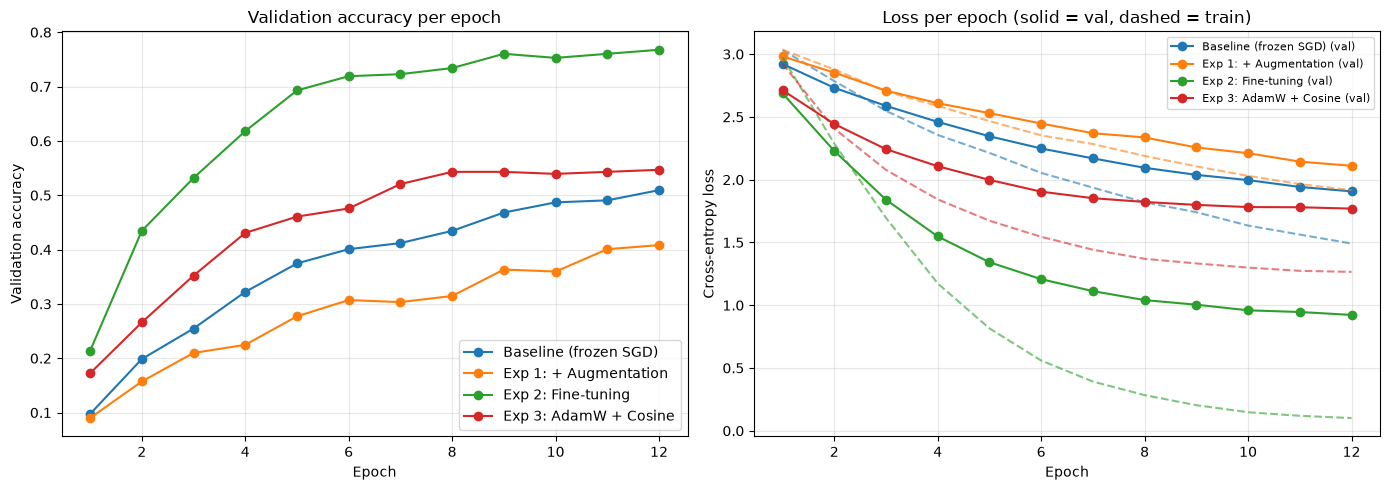

In [2]:
exp_keys = [('baseline', 'Baseline (frozen SGD)'),
            ('aug',      'Exp 1: + Augmentation'),
            ('finetune', 'Exp 2: Fine-tuning'),
            ('adamw',    'Exp 3: AdamW + Cosine')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


for key, label in exp_keys:
    epochs = range(1, len(histories[key]['val_acc']) + 1)
    ax1.plot(epochs, histories[key]['val_acc'], marker='o', label=label)
ax1.set_title('Validation accuracy per epoch')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation accuracy')
ax1.grid(True, alpha=0.3); ax1.legend()


for key, label in exp_keys:
    epochs = range(1, len(histories[key]['train_loss']) + 1)
    line, = ax2.plot(epochs, histories[key]['val_loss'], marker='o', label=f"{label} (val)")
    ax2.plot(epochs, histories[key]['train_loss'], linestyle='--',
             color=line.get_color(), alpha=0.6)
ax2.set_title('Loss per epoch (solid = val, dashed = train)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-entropy loss')
ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Validation-accuracy comparison

Best validation accuracy reached by each model

In [3]:
baseline_acc = histories['baseline']['best_val_acc']
print(f"{'Model':<28}{'Best val acc':>14}    {'diff from baseline':>16}")
print('-' * 65)
for key, label in exp_keys:
    acc = histories[key]['best_val_acc']
    delta = acc - baseline_acc
    tag = '' if key == 'baseline' else f"{delta:+.4f}"
    print(f"{label:<28}{acc:>14.4f}{tag:>16}")

Model                         Best val acc    diff from baseline
-----------------------------------------------------------------
Baseline (frozen SGD)               0.5094                
Exp 1: + Augmentation               0.4082         -0.1011
Exp 2: Fine-tuning                  0.7678         +0.2584
Exp 3: AdamW + Cosine               0.5468         +0.0375


## Best model -> evaluated on the test set

In [4]:
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds  = (0.229, 0.224, 0.225)


eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(imagenet_means, imagenet_stds),
])

for root, dirs, _ in os.walk(DATA_ROOT):
    for d in list(dirs):
        if d == '.ipynb_checkpoints':
            shutil.rmtree(os.path.join(root, d))
            print(f"Removed stray {os.path.join(root, d)}")

test_dataset = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, 'test'),
                                                transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

assert test_dataset.classes == class_names, "test class order differs from the saved class order"
print(f"Test images: {len(test_dataset)} across {len(test_dataset.classes)} classes")


model = torchvision.models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(torch.load('best_model.pth', map_location=device, weights_only=True))
model = model.to(device)
model.eval()   
print("Loaded best_model.pth")


Test images: 669 across 20 classes
Loaded best_model.pth


In [5]:
all_labels, all_preds = [], []
with torch.no_grad():                      
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets.numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)


avg_per_class_acc = balanced_accuracy_score(all_labels, all_preds)
overall_acc = (all_preds == all_labels).mean()

macro_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Overall test accuracy        : {overall_acc:.4f}")
print(f"Average per-class accuracy   : {avg_per_class_acc:.4f}   (target > 0.75)")
print(f"Macro-averaged F1            : {macro_f1:.4f}")
print("PASS" if avg_per_class_acc > 0.75 else "BELOW TARGET")


final_train_acc = histories["best"]["train_acc"][-1]
print(f"Final model training accuracy: {final_train_acc:.2f}"
      f"   gap to test: {final_train_acc - overall_acc:.2f}")


Overall test accuracy        : 0.8146
Average per-class accuracy   : 0.8148   (target > 0.75)
Macro-averaged F1            : 0.8152
PASS
Final model training accuracy: 1.00   gap to test: 0.19


### Confusion matrix

The confusion matrix shows where the model confuses visually similar aircraft

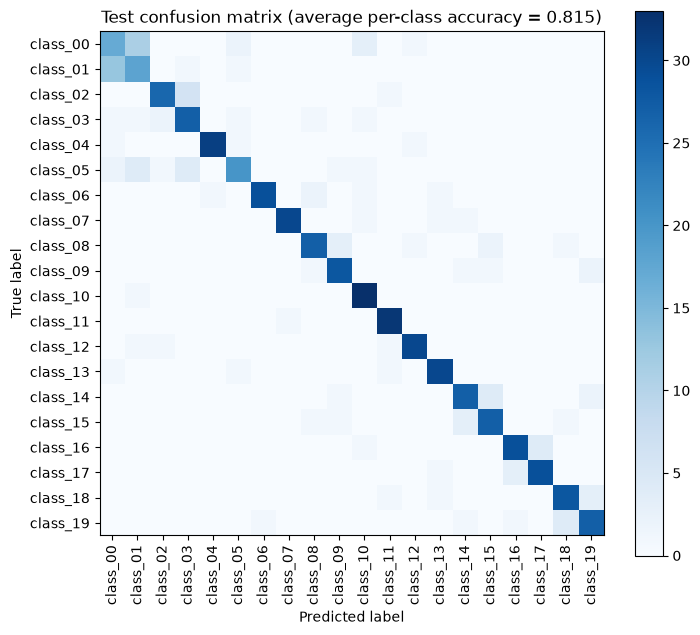

In [6]:
cm = confusion_matrix(all_labels, all_preds)


fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation='vertical', colorbar=True, cmap='Blues', include_values=False)
ax.set_title(f'Test confusion matrix (average per-class accuracy = {avg_per_class_acc:.3f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200, bbox_inches='tight') 
plt.show()


In [7]:
per_class = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class)

print(f"{'Class':<12}{'Accuracy':>10}")
print('-' * 22)
for i in order:
    print(f"{class_names[i]:<12}{per_class[i]:>10.3f}")
print('-' * 22)
print(f"{'MEAN':<12}{per_class.mean():>10.3f}")


STRONG = 0.87
print()
print(f"Classes scoring above {STRONG:.2f}: "
      f"{int((per_class > STRONG).sum())} of {num_classes}")
print(f"Weakest class: {class_names[order[0]]} at {per_class[order[0]]:.3f}")


Class         Accuracy
----------------------
class_00         0.500
class_01         0.545
class_05         0.606
class_02         0.788
class_03         0.794
class_08         0.794
class_14         0.794
class_19         0.794
class_15         0.818
class_09         0.848
class_18         0.848
class_06         0.853
class_16         0.853
class_17         0.879
class_13         0.909
class_07         0.909
class_12         0.909
class_04         0.912
class_11         0.970
class_10         0.971
----------------------
MEAN             0.815

Classes scoring above 0.87: 7 of 20
Weakest class: class_00 at 0.500


### Results from Confusion Matrix

In [8]:
# The classes which were wrongly predicted
off = cm.copy()
np.fill_diagonal(off, 0)          
pairs = sorted(((off[i, j], i, j)
                for i in range(num_classes) for j in range(num_classes) if off[i, j] > 0),
               reverse=True)

print(f"{'True class':<12}{'Predicted':<14}{'Images':>7}")
print('-' * 33)
for n, i, j in pairs[:8]:
    print(f"{class_names[i]:<12}{class_names[j]:<14}{n:>7d}")


True class  Predicted      Images
---------------------------------
class_01    class_00           13
class_00    class_01           11
class_02    class_03            6
class_19    class_18            4
class_16    class_17            4
class_14    class_15            4
class_05    class_03            4
class_05    class_01            4
